In [1]:
import os
import numpy as np
import math
import matplotlib.pyplot as plt

import scipy as sp
import scipy.linalg
import scipy.optimize

import glob

from natsort import natsorted

# # import lsqfit
# from lib import Jackknife
# from lib import simple_mean
# from lib import format_print

# plt.rcParams['figure.dpi'] = 300

In [2]:
class Jackknife:
    def __init__( self, len_data, binsize ):
        self.binsize = binsize
        self.nbins = math.floor( len_data/self.binsize )
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0

    def set( self, func, list_of_data ):
        for i in range( self.nbins ):
            self.jack_avg.append( func( i, self.binsize, list_of_data ) )

    def do_it( self ):
        for i in range( 0, self.nbins ):
            self.est += self.jack_avg[i]
        self.est /= self.nbins

        for i in range( 0, self.nbins ):
            self.var_est += ( self.jack_avg[i] - self.est )**2
        self.var_est /= self.nbins
        self.var_est *= self.nbins -1

    def mean( self ):
        return self.est

    def var( self ):
        return self.var_est

    def err( self ):
        return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    return np.mean(resmpld, axis=0)

def jack_avg(i, binsize, np_data):
    return np_data[i]

def take_abs(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )

    return np.sqrt(mean.T[1]**2 + mean.T[2]**2)


def take_real(i, binsize, np_data):
    resmpld = np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0)
    mean = np.mean(resmpld, axis=0)
    # mean = mean[1:int(Nt/2)] + np.flip( mean[int(Nt/2):Nt-1], axis=0 )
    return mean.T[1]


def format_print(cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'

def format_print_w_exact(exact, cen, err):
    for i in range(-50, 50):
        if 10**(-i+1)>=err>10**(-i):
            tmp=err*10**(i+1)
            return '{num:.{width}f}'.format(num=cen, width=i+1)+'('+str(round(tmp))+')'+': '+'{num:.{width}f}'.format(num=(exact-cen)/err, width=i+1)+' sigma'

In [3]:
pwd

'/mnt/barracuda22/qed3/qed3/src/both_3d'

In [4]:
# dir1='/projectnb/qfe/nmatsum/qed3/src/both_3d/'
# dir1='/media/nobu/baracuda_14/qed3/qed3/src/both_3d/'
dir1='/mnt/barracuda22/qed3/qed3/src/both_3d/'

In [5]:
results=[]

In [6]:
dir1+"data_free_vmRe0.000000vmIm0.000000/corr_deter_exact_L1"

'/mnt/barracuda22/qed3/qed3/src/both_3d/data_free_vmRe0.000000vmIm0.000000/corr_deter_exact_L1'

In [7]:
# Nf=2

# # gsq="8.000000"
# gsq="4.000000"
# # gsq="1.000000"
# # gsq="0.500000"
# # gsq="0.100000"

# # nu0="0.800000"
# # nu0="2.000000"
# nu0="2.000000"

# nu1="3.000000" # nu0 # "1.000000"
# # nu1="2.000000"
# # nu1="1.000000"

# at="0.200000"
# Nt=96
# L=1

# Lattice JJ local-current check: Eqs. (4.28)/(4.31)/(4.35) vs the LATTICE overlap propagator

Test of `jj_local_deter_claude.cu` (local / ultralocal current) fed the **lattice overlap
propagator** $D_m^{-1}$ (the actual $D_\text{ov}^{-1}$ on the simplicial lattice, built by
`jj_propagator_deter_claude.cu` via dense LU):

    ./jj_local_deter_L<L>.o --n-t0 2      # free; reads prop_deter_L<L>/Dinv.0.h5

writing `data_free_vmRe0.000000vmIm0.000000/corr_deter_local_L<L>/corr.0.h5` (no `--prop-file`,
no `--out-tag`).

This is the companion of `checkCFT_claude.ipynb` (which fed the analytic **continuum** propagator).
Here the propagator carries lattice artifacts, so we compare $L=1$ (12 sites) vs $L=2$ (42 sites)
to see the approach to the CFT predictions.  Same site-object Pauli channels `s1,s2,s3`
($G_t=$`s3`, Eq. 4.31; $G_s=$`s1`+`s2`, Eq. 4.28) and the Ylm tower `ylm/l{0,1,2}` (Eq. 4.35);
$t=a_t\,n_t$, $a_t=0.2$.

Note: the lattice same-site block need **not** be exactly $c_3(t)\sigma_3$, so $G_s/G_t$ may deviate
from $-2$ and the Ylm rates/ratio from $(2,3)$/$2.4$ at finite $a$ -- that deviation, and its trend
with $L$, is the point of the comparison.

In [8]:
import h5py

at_cft = 0.2
Nt_cft = 128
L_cft  = 1

# dir1 is set near the top of the notebook (the both_3d/ path)
ESN_cft = dir1 + "data_free_vmRe0.000000vmIm0.000000/"

def load_Vpp(corrdir, proj, origin="t0_0", k=0):
    # jj_local_deter_claude.cu output: h0/<origin>/<proj>/Vpp ; proj = "s1","s2","s3".
    # Each is a diagonal Pauli channel <sigma_a sigma_a> (site object).  G_t = s3 (Eq.4.31),
    # G_s = s1 + s2 (Eq.4.28).  disc (one-point) ~0 here, so Vpp is the connected correlator.
    path = ESN_cft + corrdir + "/corr." + str(k) + ".h5"
    with h5py.File(path, "r") as f:
        key = "h0/" + origin + "/" + proj + "/Vpp"
        return f[key+"/real"][()] + 1j*f[key+"/imag"][()]

In [9]:
# qed3int_v2-11  Eqs. (4.28)/(4.31), same-site, Delta = D - 1 = 2
Delta_cft = 2.0

def cft_shape(t):
    return np.exp(-Delta_cft*t) * (1.0 - np.exp(-t))**(-2.0*Delta_cft)

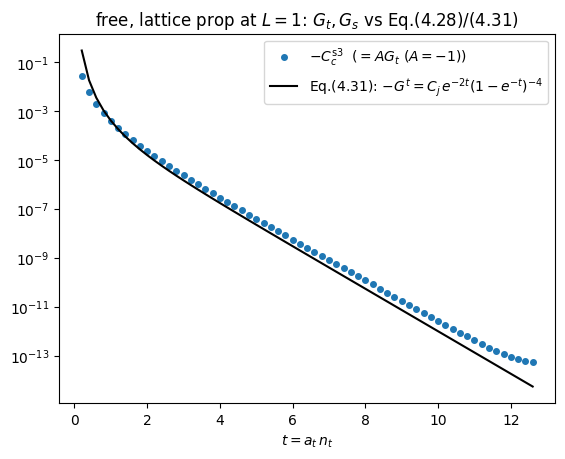

In [10]:
# G_t = s3, G_s = s1+s2 vs the Eq.(4.28)/(4.31) shape (magnitude, log scale)
corrdir = "corr_deter_local_L1"

gt = load_Vpp(corrdir, "s3").real
gs = (load_Vpp(corrdir, "s1") + load_Vpp(corrdir, "s2")).real

dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

# fix the undetermined overall scale of the CFT curve by matching |G_t| at one separation
ref = 5
Cj = -gt[ref] / cft_shape(t[ref-1])

plt.figure()
plt.plot(t, -gt[dt], 'o', ms=4, label="$-C_c^{\\rm s3}$  ($ = A G_t$ ($A=-1$))")
# plt.plot(t, gs[dt], 's', ms=4, label="lattice $G_s$ (s1+s2)")
plt.plot(t, Cj*cft_shape(t), 'k-',
         label=r"Eq.(4.31): $-G^t = C_j \, e^{-2t}(1-e^{-t})^{-4}$")
plt.yscale("log")
plt.xlabel(r"$t = a_t\, n_t$")
plt.title("free, lattice prop at $L=1$: $G_t,G_s$ vs Eq.(4.28)/(4.31)")
plt.legend()
plt.savefig("cft_GtGs_lat_L1.pdf", bbox_inches="tight")

In [19]:
Cj

np.float64(0.00048722974192967015)

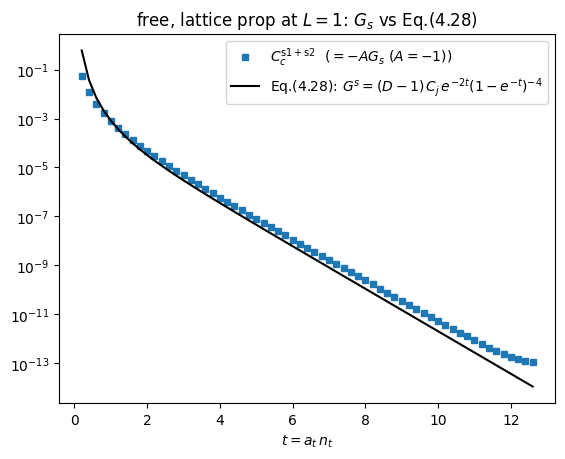

In [11]:
# sp counterpart: G_s = s1 + s2 vs Eq.(4.28) (magnitude, log scale).
# Eq.(4.28): G_s = +C_J (D-1) e^{-Delta t}(1-e^{-t})^{-2 Delta}, so Re G_s > 0 (opposite to G_t).
corrdir = "corr_deter_local_L1"

gs = (load_Vpp(corrdir, "s1") + load_Vpp(corrdir, "s2")).real

dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

plt.figure()
plt.plot(t, gs[dt], 's', ms=4, label="$C_c^{\\rm s1+s2}$  ($ = -A G_s$ ($A=-1$))")
plt.plot(t, 2.0*Cj*cft_shape(t), 'k-',
         label=r"Eq.(4.28): $G^s = (D-1) \, C_j\,e^{-2t}(1-e^{-t})^{-4}$")
plt.yscale("log")
plt.xlabel(r"$t = a_t\, n_t$")
plt.title("free, lattice prop at $L=1$: $G_s$ vs Eq.(4.28)")
plt.legend()
plt.savefig("cft_Gs_lat_L1.pdf", bbox_inches="tight")

In [12]:
gs[dt] / gt[dt]

array([-2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.,
       -2., -2., -2., -2., -2., -2., -2., -2., -2., -2., -2.])

## Ylm tower — Eq. (4.35)  [qed3int_v2-11]

Spherical-harmonic descendants of the temporal current correlator $G_t$ (the `s3` channel). The
diagonal-$m$ Legendre coefficient (HDF5 key `ylm/l{0,1,2}`),

$$g_\ell(t)\equiv G^t_{\ell\ell}(t)=\frac{1}{2\ell+1}\sum_{m=-\ell}^{\ell}\big\langle j_{\ell m}(t_0)\,j_{\ell m}(t)\big\rangle,
\qquad j_{\ell m}(t)=\sum_n A_n\,Y_{\ell m}(\hat n)\,\sigma_3(n,t),$$

is the lattice quadrature of $\tfrac12\int_{-1}^{1}G_t(t;x)P_\ell(x)\,dx$ (same lattice overlap propagator as
`jj_cft_ylm_check_claude.cc`, summed over the $L=1$ sites). Prediction (Eq. 4.35, $\Delta=2$,
$C_j=-1/(8\pi^2)$):

$$G^t_{11}(t)\to \tfrac{1}{24\pi^2}e^{-2t},\qquad G^t_{22}(t)\to \tfrac{1}{10\pi^2}e^{-3t},\qquad G^t_{00}\to 0.$$

Convention-free checks: decay rates $(2,3)$ for $\ell=(1,2)$; ratio $G^t_{22}e^{3t}/G^t_{11}e^{2t}\to 12/5=2.4$;
$G^t_{00}/G^t_{11}\to 0$.

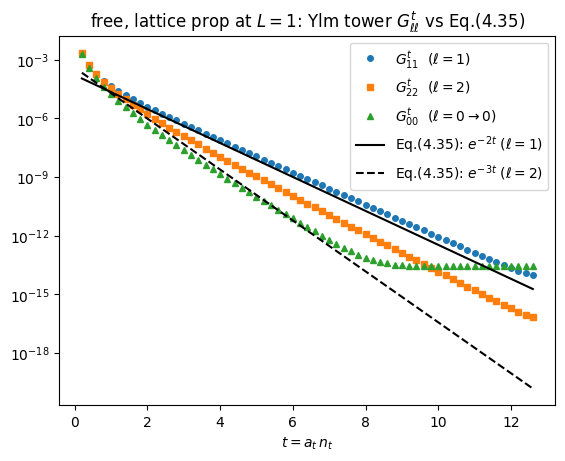

In [13]:
# Ylm tower g_l(t) (HDF5 key ylm/l{0,1,2}) vs Eq.(4.35) shapes (magnitude, log scale)
corrdir = "corr_deter_local_L1"

g0 = load_Vpp(corrdir, "ylm/l0").real
g1 = load_Vpp(corrdir, "ylm/l1").real
g2 = load_Vpp(corrdir, "ylm/l2").real

dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

# CFT shapes, amplitude matched at one separation each (overall C_j undetermined)
ref = 5

plt.figure()
plt.plot(t, -g1[dt], 'o', ms=4, label=r"$G^t_{11}$  ($\ell=1$)")
plt.plot(t, -g2[dt], 's', ms=4, label=r"$G^t_{22}$  ($\ell=2$)")
plt.plot(t, g0[dt], '^', ms=4, label=r"$G^t_{00}$  ($\ell=0\to0$)")
plt.plot(t, (1.0/3.0)*Cj*np.exp(-2.0*t), 'k-',  label=r"Eq.(4.35): $e^{-2t}$ ($\ell=1$)")
plt.plot(t, (4.0/5.0)*Cj*np.exp(-3.0*t), 'k--', label=r"Eq.(4.35): $e^{-3t}$ ($\ell=2$)")
plt.yscale("log")
plt.xlabel(r"$t = a_t\, n_t$")
plt.title("free, lattice prop at $L=1$: Ylm tower $G^t_{\\ell\\ell}$ vs Eq.(4.35)")
plt.legend()
plt.savefig("cft_ylm_lat_L1.pdf", bbox_inches="tight")

predicted rates: l=1 -> 2.0,  l=2 -> 3.0
l=1 rate (mid t): [1.942 1.933 1.926 1.92  1.916 1.912 1.908]
l=2 rate (mid t): [2.439 2.416 2.396 2.379 2.363 2.349 2.337]

predicted ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4
ratio (mid t): [3.9309 4.3042 4.7299 5.2149 5.7672 6.3958 7.111  7.9248]

g0/g1 -> 0 : [0.064  0.0528 0.0438 0.0366 0.0308 0.026  0.022  0.0188]


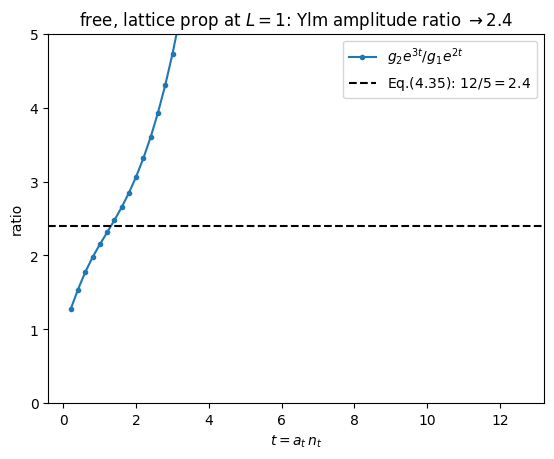

In [14]:
# Convention-free Eq.(4.35) checks: decay rates -> (2,3); ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4; g0/g1 -> 0
dt = np.arange(1, int(Nt_cft/2))
t  = dt * at_cft

# effective decay rate  m_eff(t) = -(1/at) log( g[n+1]/g[n] )
def eff_rate(g):
    gg = g[dt]
    return -np.log(gg[1:]/gg[:-1]) / at_cft

print("predicted rates: l=1 -> 2.0,  l=2 -> 3.0")
print("l=1 rate (mid t):", np.round(eff_rate(g1)[15:22], 3))
print("l=2 rate (mid t):", np.round(eff_rate(g2)[15:22], 3))

ratio = (g2[dt]*np.exp(3.0*t)) / (g1[dt]*np.exp(2.0*t))
print("\npredicted ratio g2 e^{3t}/g1 e^{2t} -> 12/5 = 2.4")
print("ratio (mid t):", np.round(ratio[12:20], 4))
print("\ng0/g1 -> 0 :", np.round((g0[dt]/g1[dt])[12:20], 4))

plt.figure()
plt.plot(t, ratio, '.-', label=r"$g_2 e^{3t}/g_1 e^{2t}$")
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r"Eq.(4.35): $12/5 = 2.4$")
plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel("ratio"); plt.ylim(0, 5)
plt.title("free, lattice prop at $L=1$: Ylm amplitude ratio $\\to 2.4$")
plt.legend()
plt.savefig("cft_ylm_ratio_L1.pdf", bbox_inches="tight")

## $L$-convergence: $L=1,2,4$  (lattice prop)

The same deterministic local-current trace fed the LATTICE overlap propagator
`prop_deter_L{1,2,4}/Dinv.0.h5` (output dirs `corr_deter_local_L{1,2,4}`). Compare $L=1$ (12 sites)
vs $L=2$ (42 sites) vs $L=4$ (162 sites). Unlike the continuum-propagator notebook, $G_t,G_s$ and the
Ylm tower all carry lattice artifacts at finite $a$, so they need **not** sit exactly on the CFT
curves -- the point is how they move toward Eq.(4.31)/(4.28) (shape, ratio $-2$) and Eq.(4.35)
(rates $(2,3)$, ratio $2.4$) as $L$ grows.

(Run the $L=1,2,4$ lattice jobs first -- see `tmp_lat_claude.sh`; $L=4$ loads the dense $D_m^{-1}$,
$\sim$41 GB RAM.)

In [ ]:
# G_t (s3) overlay for L=1,2,4 (lattice prop) vs Eq.(4.31).
# Lattice overlap -> NOT exact same-site; the curves carry lattice artifacts and shift with L.
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
ref = 5

# CFT reference amplitude anchored to L=1 G_t (visual only; lattice norm is not predicted)
CjL = None
for L in [1, 2, 4]:
    try:
        gtL = load_Vpp("corr_deter_local_L%d" % L, "s3").real
        CjL = -gtL[ref] / cft_shape(t[ref-1]); break
    except (OSError, KeyError):
        pass

plt.figure()
for L in [1, 2, 4]:
    cd = "corr_deter_local_L%d" % L
    try:
        gt = load_Vpp(cd, "s3").real
    except (OSError, KeyError):
        print("missing:", cd); continue
    plt.plot(t, -gt[dt], 'o', ms=3, label="L=%d" % L)
if CjL is not None:
    plt.plot(t, CjL*cft_shape(t), 'k-', label="Eq.(4.31)")
plt.yscale("log"); plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel(r"$-G_t$ (s3)")
plt.title("lattice prop, $L=1,2,4$: $-G_t$ (s3) vs Eq.(4.31)")
plt.legend()
plt.savefig("cft_Gt_lat_L124.pdf", bbox_inches="tight")

In [ ]:
# G_s (s1+s2) overlay for L=1,2,4 (lattice prop) vs Eq.(4.28).
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
ref = 5

# CFT reference amplitude anchored to L=1 G_t (visual only; lattice norm is not predicted)
CjL = None
for L in [1, 2, 4]:
    try:
        gtL = load_Vpp("corr_deter_local_L%d" % L, "s3").real
        CjL = -gtL[ref] / cft_shape(t[ref-1]); break
    except (OSError, KeyError):
        pass

plt.figure()
for L in [1, 2, 4]:
    cd = "corr_deter_local_L%d" % L
    try:
        gs = (load_Vpp(cd, "s1") + load_Vpp(cd, "s2")).real
    except (OSError, KeyError):
        print("missing:", cd); continue
    plt.plot(t, gs[dt], 's', ms=3, label="L=%d" % L)
if CjL is not None:
    plt.plot(t, 2.0*CjL*cft_shape(t), 'k-', label="Eq.(4.28)")
plt.yscale("log"); plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel(r"$G_s$ (s1+s2)")
plt.title("lattice prop, $L=1,2,4$: $G_s$ (s1+s2) vs Eq.(4.28)")
plt.legend()
plt.savefig("cft_Gs_lat_L124.pdf", bbox_inches="tight")

In [16]:
!

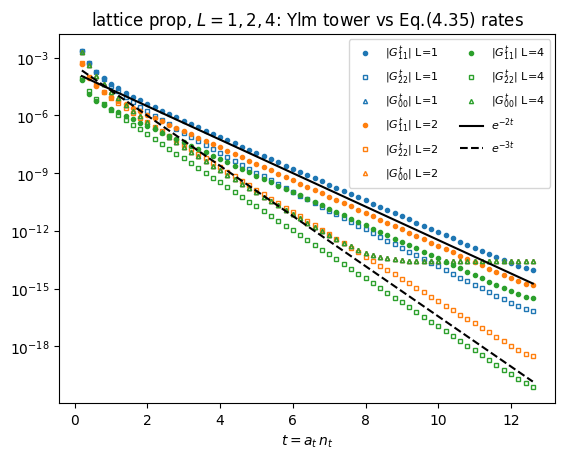

In [17]:
# Ylm tower |G^t_11|, |G^t_22| overlay for L=1,2 vs Eq.(4.35) (off-site quadrature -> converges with L)
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft
col = {1: 'C0', 2: 'C1', 4: 'C2'}

plt.figure()
gref = None
for L in [1, 2, 4]:
    cd = "corr_deter_local_L%d" % L
    try:
        g1 = load_Vpp(cd, "ylm/l1").real
        g2 = load_Vpp(cd, "ylm/l2").real
    except (OSError, KeyError):
        print("missing:", cd); continue
    if gref is None: gref = g1
    plt.plot(t, g1[dt], 'o', ms=3, color=col[L],            label=r"$|G^t_{11}|$ L=%d" % L)
    plt.plot(t, g2[dt], 's', ms=3, color=col[L], mfc='none', label=r"$|G^t_{22}|$ L=%d" % L)
    plt.plot(t, g0[dt], '^', ms=3, color=col[L], mfc='none', label=r"$|G^t_{00}|$ L=%d" % L)
# reference slopes (matched to the first available L at one separation)
if gref is not None:
    A1 = gref[5] / np.exp(-2.0*t[4])
    plt.plot(t, (1.0/3.0)*Cj*np.exp(-2.0*t), 'k-',  label=r"$e^{-2t}$")
    plt.plot(t, (4.0/5.0)*Cj*np.exp(-3.0*t), 'k--', label=r"$e^{-3t}$")
plt.yscale("log"); plt.xlabel(r"$t = a_t\, n_t$")
plt.title("lattice prop, $L=1,2,4$: Ylm tower vs Eq.(4.35) rates")
plt.legend(fontsize=8, ncol=2)
plt.savefig("cft_ylm_tower_lat_L124.pdf", bbox_inches="tight")

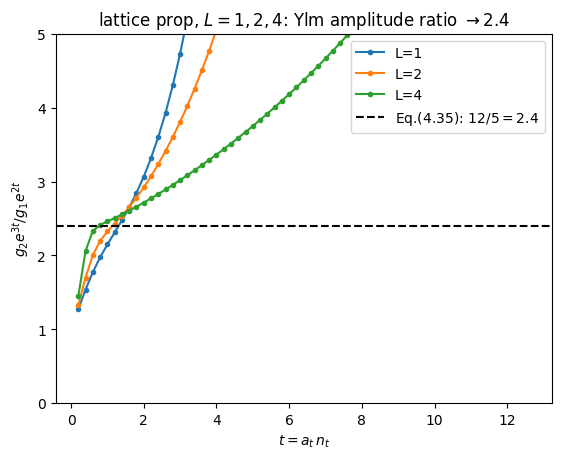

In [18]:
# Ylm ratio g2 e^{3t} / g1 e^{2t} -> 12/5 = 2.4 : convergence with L
dt = np.arange(1, int(Nt_cft/2)); t = dt*at_cft

plt.figure()
for L in [1, 2, 4]:
    cd = "corr_deter_local_L%d" % L
    try:
        g1 = load_Vpp(cd, "ylm/l1").real
        g2 = load_Vpp(cd, "ylm/l2").real
    except (OSError, KeyError):
        print("missing:", cd); continue
    plt.plot(t, (g2[dt]*np.exp(3.0*t))/(g1[dt]*np.exp(2.0*t)), '.-', label="L=%d" % L)
plt.axhline(12.0/5.0, color='k', ls='dashed', label=r"Eq.(4.35): $12/5 = 2.4$")
plt.xlabel(r"$t = a_t\, n_t$"); plt.ylabel(r"$g_2 e^{3t}/g_1 e^{2t}$"); plt.ylim(0, 5)
plt.title("lattice prop, $L=1,2,4$: Ylm amplitude ratio $\\to 2.4$")
plt.legend()
plt.savefig("cft_ylm_ratio_lat_L124.pdf", bbox_inches="tight")